In [84]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/commonlit-evaluate-student-summaries/sample_submission.csv
/kaggle/input/commonlit-evaluate-student-summaries/prompts_train.csv
/kaggle/input/commonlit-evaluate-student-summaries/summaries_test.csv
/kaggle/input/commonlit-evaluate-student-summaries/summaries_train.csv
/kaggle/input/commonlit-evaluate-student-summaries/prompts_test.csv


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
train = pd.read_csv('/kaggle/input/commonlit-evaluate-student-summaries/summaries_train.csv')
train.head()

,student_id,prompt_id,text,content,wording
0,000e8c3c7ddb,814d6b,The third wave was an experimentto see how peo...,0.205683,0.380538
1,0020ae56ffbf,ebad26,They would rub it up with soda to make the sme...,-0.548304,0.506755
2,004e978e639e,3b9047,"In Egypt, there were many occupations and soci...",3.128928,4.231226
3,005ab0199905,3b9047,The highest class was Pharaohs these people we...,-0.210614,-0.471415
4,0070c9e7af47,814d6b,The Third Wave developed rapidly because the ...,3.272894,3.219757


In [3]:
test = pd.read_csv('/kaggle/input/commonlit-evaluate-student-summaries/summaries_test.csv')
test.head()

,student_id,prompt_id,text
0,000000ffffff,abc123,Example text 1
1,111111eeeeee,def789,Example text 2
2,222222cccccc,abc123,Example text 3
3,333333dddddd,def789,Example text 4


In [4]:
combined = pd.concat([train,test])
combined.head()

,student_id,prompt_id,text,content,wording
0,000e8c3c7ddb,814d6b,The third wave was an experimentto see how peo...,0.205683,0.380538
1,0020ae56ffbf,ebad26,They would rub it up with soda to make the sme...,-0.548304,0.506755
2,004e978e639e,3b9047,"In Egypt, there were many occupations and soci...",3.128928,4.231226
3,005ab0199905,3b9047,The highest class was Pharaohs these people we...,-0.210614,-0.471415
4,0070c9e7af47,814d6b,The Third Wave developed rapidly because the ...,3.272894,3.219757


In [5]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7169 entries, 0 to 3
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   student_id  7169 non-null   object 
 1   prompt_id   7169 non-null   object 
 2   text        7169 non-null   object 
 3   content     7165 non-null   float64
 4   wording     7165 non-null   float64
dtypes: float64(2), object(3)
memory usage: 336.0+ KB


In [90]:
combined.dtypes

student_id     object
prompt_id      object
text           object
content       float64
wording       float64
dtype: object

In [91]:
combined.shape

(7169, 5)

In [92]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
content,7165.0,-0.014853,1.043569,-1.729859,-0.799545,-0.093814,0.499660,3.900326
wording,7165.0,-0.063072,1.036048,-1.962614,-0.872720,-0.081769,0.503833,4.310693


In [93]:
combined.shape

(7169, 5)

In [94]:
combined.columns

Index(['student_id', 'prompt_id', 'text', 'content', 'wording'], dtype='object')

In [95]:
combined.iterrows()

<generator object DataFrame.iterrows at 0x7f1411514ba0>

In [96]:
combined.skew()

/tmp/ipykernel_32/3158812268.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.skew()


content    0.726133
wording    0.564963
dtype: float64

In [97]:
combined.kurt()

/tmp/ipykernel_32/292944781.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.kurt()


content    0.314690
wording    0.362934
dtype: float64

In [98]:
combined.isnull().sum()/len(combined)*100

student_id    0.000000
prompt_id     0.000000
text          0.000000
content       0.055796
wording       0.055796
dtype: float64

In [99]:
combined.tail()

,student_id,prompt_id,text,content,wording
7164,fffbccfd8a08,ebad26,"The meat would smell sour but the would ""rub i...",1.771596,0.547742
0,000000ffffff,abc123,Example text 1,NaN,NaN
1,111111eeeeee,def789,Example text 2,NaN,NaN
2,222222cccccc,abc123,Example text 3,NaN,NaN
3,333333dddddd,def789,Example text 4,NaN,NaN


<Axes: >

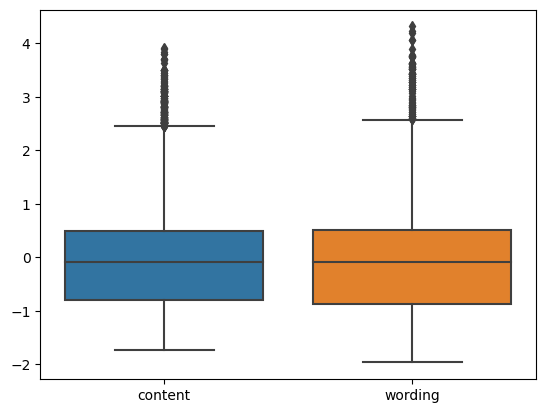

In [100]:
sns.boxplot(combined)

<Axes: >

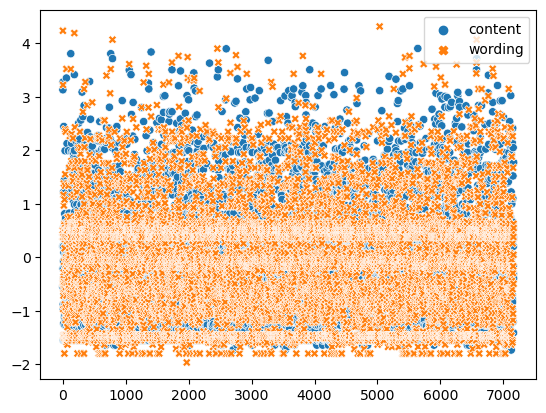

In [101]:
sns.scatterplot(combined)

In [102]:
Q1 = combined.quantile(0.25)
Q2 = combined.quantile(0.5)
Q3 = combined.quantile(0.75)
IQR=Q3-Q1
print(IQR)

content    1.299205
wording    1.376553
dtype: float64


/tmp/ipykernel_32/2240195514.py:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = combined.quantile(0.25)
/tmp/ipykernel_32/2240195514.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q2 = combined.quantile(0.5)
/tmp/ipykernel_32/2240195514.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = combined.quantile(0.75)


In [103]:
UL = Q3+(1.5*IQR)
LL = Q1-(1.5*IQR)

In [104]:
combined_new = combined[~((combined>UL)|(combined<LL)).any(axis=1)]

/tmp/ipykernel_32/1551434999.py:1: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  combined_new = combined[~((combined>UL)|(combined<LL)).any(axis=1)]


In [105]:
combined_new.shape

(6969, 5)

<Axes: >

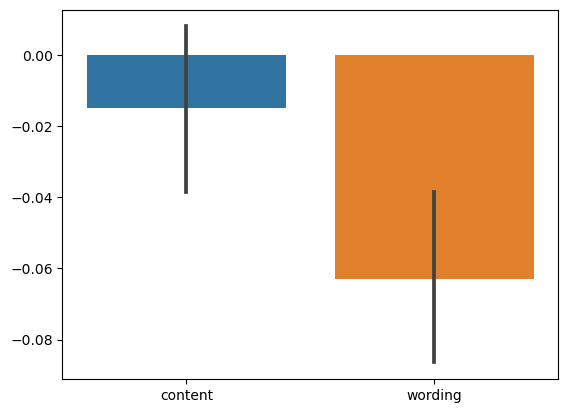

In [106]:
sns.barplot(combined)

<Axes: ylabel='Density'>

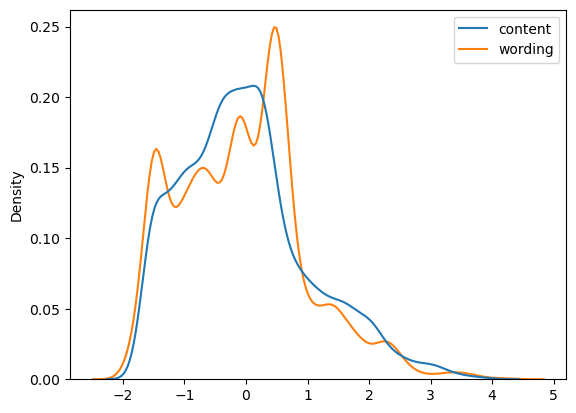

In [107]:
sns.kdeplot(combined)

<Axes: >

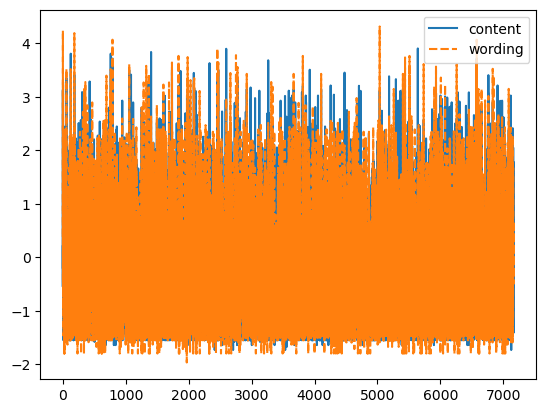

In [108]:
sns.lineplot(combined)

/tmp/ipykernel_32/1658940522.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True)


<Axes: >

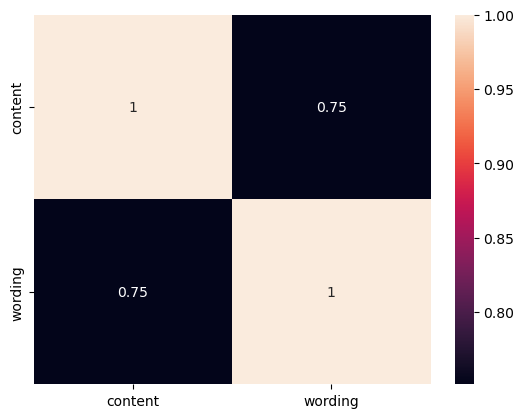

In [109]:
sns.heatmap(combined.corr(),annot=True)

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


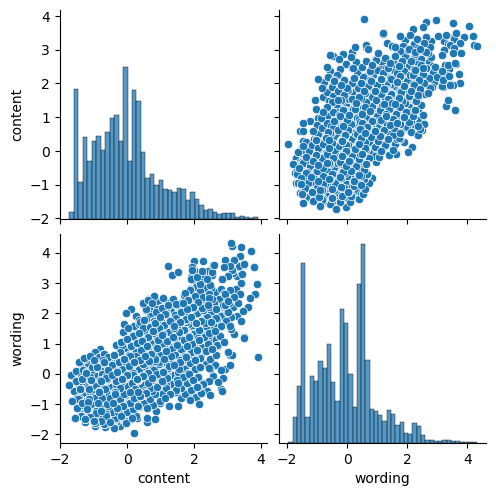

In [114]:
sns.pairplot(combined)

In [115]:
cat_cols = combined.select_dtypes(include='object')

In [116]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

student_id
000e8c3c7ddb    1
7f0b9e5dd189    1
a9cde51758e6    1
a9bd38723b5c    1
a9bbdab6203d    1
               ..
5505d5e81ce6    1
54f872b66565    1
54ec1d27bae3    1
54d3b82ff5b1    1
333333dddddd    1
Name: student_id, Length: 7169, dtype: int64
__________________________________________________
prompt_id
39c16e    2057
3b9047    2009
ebad26    1996
814d6b    1103
abc123       2
def789       2
Name: prompt_id, dtype: int64
__________________________________________________
text
The third wave was an experimentto see how people reacted to a new one leader government. It gained popularity as people wanted to try new things. The students follow anything that is said and start turning on eachother to gain higher power. They had to stop the experement as too many people got to radical with it blindly following there leader                                                                                                                                                                   

In [117]:
num_cols = combined.select_dtypes(include='number')

In [118]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

content
-1.547163    426
 0.205683    380
-0.093814    286
-1.264214    173
 0.297031    171
            ... 
 1.388088      1
 1.249104      1
 1.970533      1
 2.160927      1
 1.520355      1
Name: content, Length: 1134, dtype: int64
__________________________________________________
wording
-1.461245    426
 0.380538    380
 0.503833    286
-1.505073    173
-0.168734    171
            ... 
 1.207819      1
 0.240178      1
 1.040696      1
 1.420841      1
-0.292990      1
Name: wording, Length: 1134, dtype: int64
__________________________________________________


In [119]:
combined['student_id']=combined['student_id'].map({"Good":2,'Standard':1,'Poor':0})

/tmp/ipykernel_32/401063577.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')


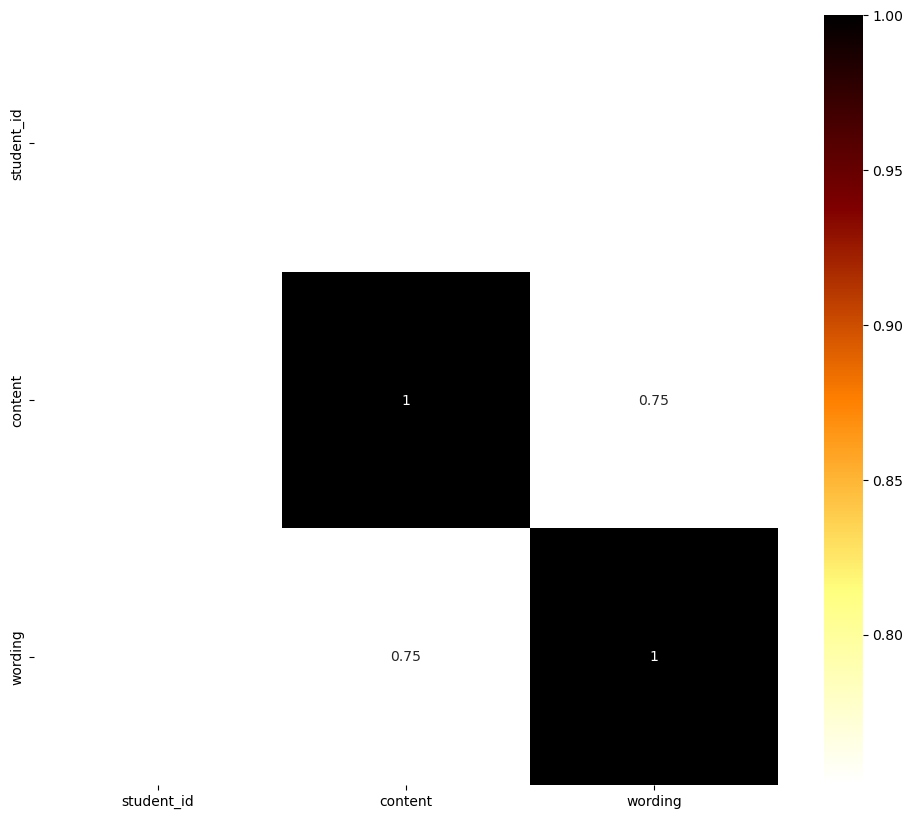

In [120]:
plt.figure(figsize=(12,10))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,


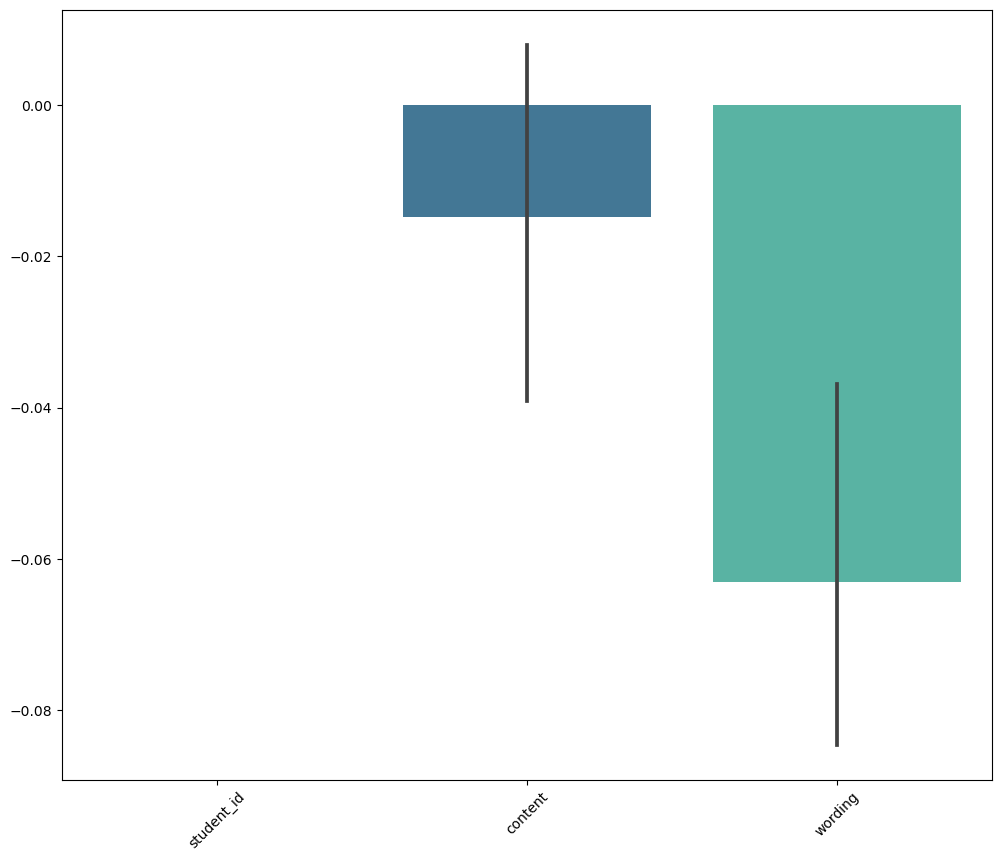

In [121]:
plt.figure(figsize=(12,10))
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=45);

(array([0, 1, 2]),
 [Text(0, 0, 'student_id'), Text(1, 0, 'content'), Text(2, 0, 'wording')])

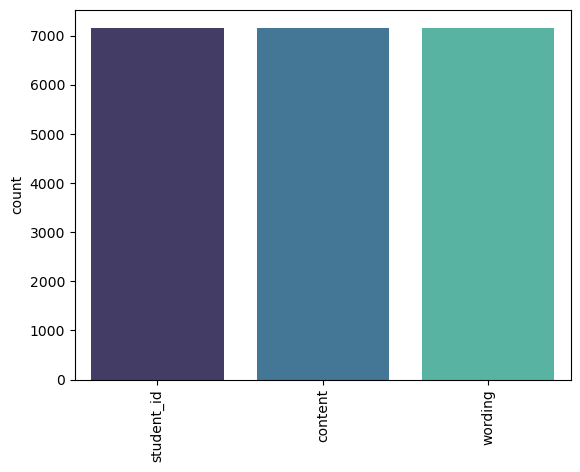

In [122]:
sns.countplot(data=combined,palette='mako')
plt.xticks(rotation=90)

(array([-3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.]),
 [Text(-3.0, 0, '−3'),
  Text(-2.0, 0, '−2'),
  Text(-1.0, 0, '−1'),
  Text(0.0, 0, '0'),
  Text(1.0, 0, '1'),
  Text(2.0, 0, '2'),
  Text(3.0, 0, '3'),
  Text(4.0, 0, '4'),
  Text(5.0, 0, '5')])

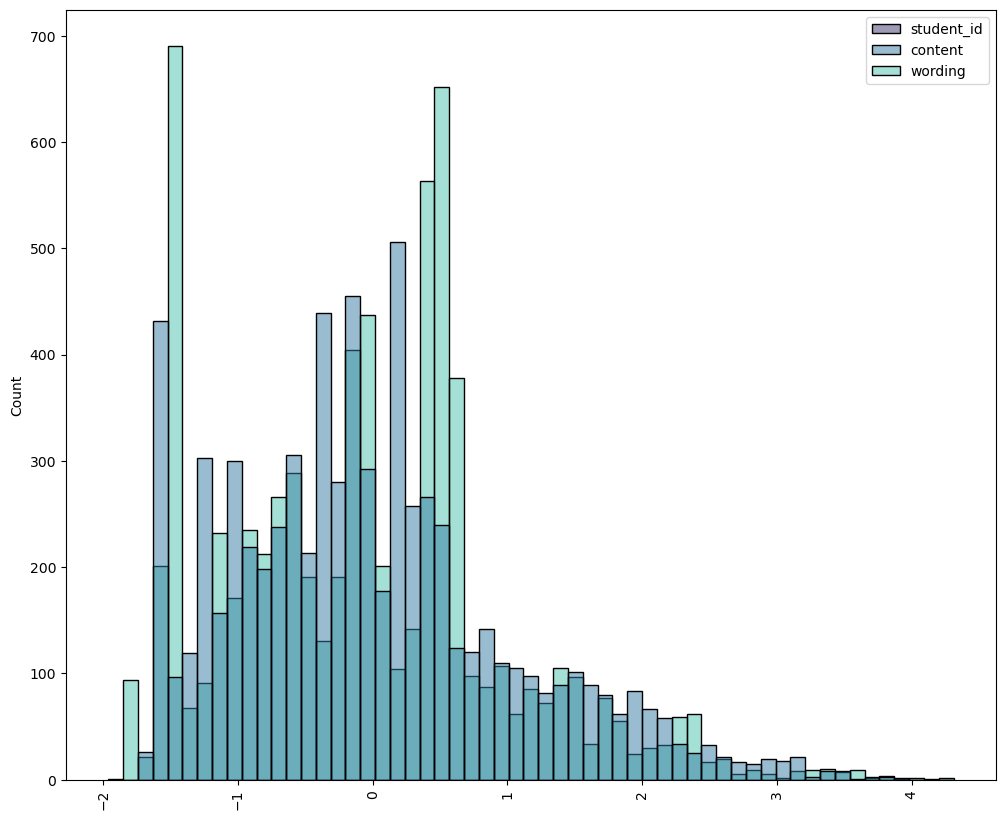

In [123]:
plt.figure(figsize=(12,10))
sns.histplot(data=combined,palette='mako')
plt.xticks(rotation=90)

In [124]:
combined['prompt_id'].value_counts()

39c16e    2057
3b9047    2009
ebad26    1996
814d6b    1103
abc123       2
def789       2
Name: prompt_id, dtype: int64

In [125]:
combined['prompt_id'].unique()

array(['814d6b', 'ebad26', '3b9047', '39c16e', 'abc123', 'def789'],
      dtype=object)

<Axes: ylabel='Count'>

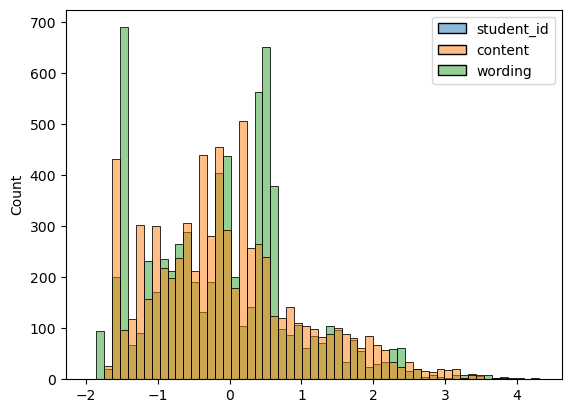

In [126]:
sns.histplot(combined)

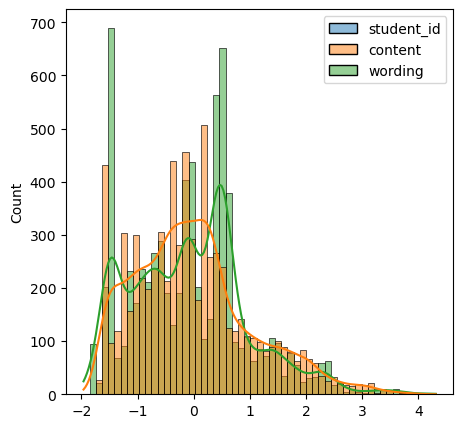

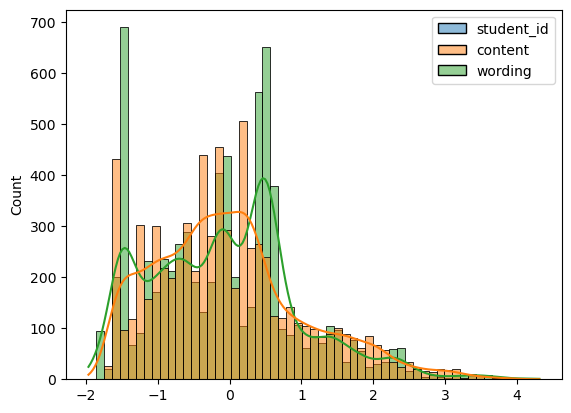

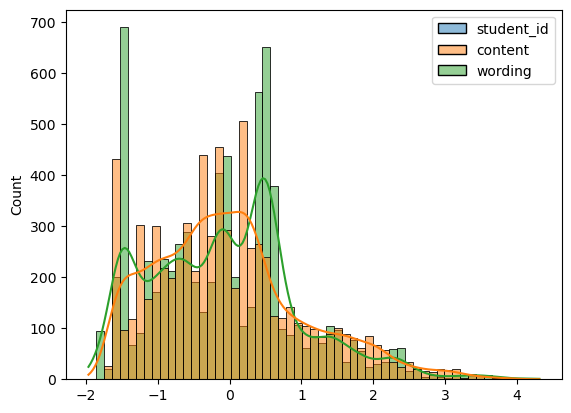

In [127]:
plt.figure(figsize=(5,5))
x=1
for i in cat_cols:
    sns.histplot(data=combined,kde=True)
    print('\n')
    plt.show()

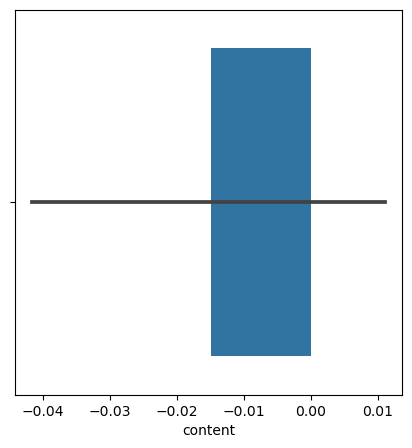

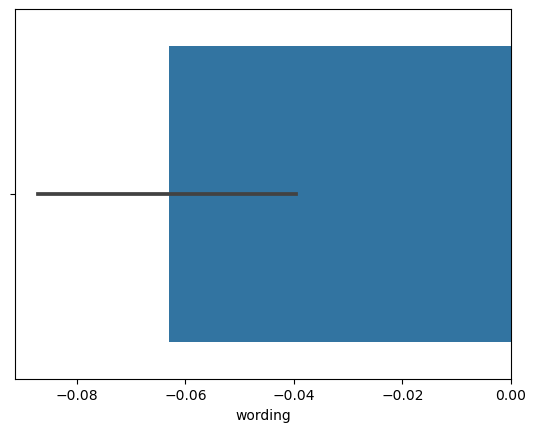

In [113]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.barplot(data=combined,x=i)
    print('\n')
    plt.show()


In [128]:
combined.head(
)

,student_id,prompt_id,text,content,wording
0,NaN,814d6b,The third wave was an experimentto see how peo...,0.205683,0.380538
1,NaN,ebad26,They would rub it up with soda to make the sme...,-0.548304,0.506755
2,NaN,3b9047,"In Egypt, there were many occupations and soci...",3.128928,4.231226
3,NaN,3b9047,The highest class was Pharaohs these people we...,-0.210614,-0.471415
4,NaN,814d6b,The Third Wave developed rapidly because the ...,3.272894,3.219757


In [129]:
# Treating null of prompt_id with help of student_id
combined['prompt_id'].isnull().sum()/len(combined)

0.0

In [130]:
combined['prompt_id']=combined['prompt_id'].fillna(combined['prompt_id'].mode()[0])

In [131]:
combined['content']=combined['content'].fillna(combined['content'].mode()[0])

In [132]:
combined['wording']=combined['wording'].fillna(combined['wording'].mode()[0])

In [133]:
combined.isnull().sum()

student_id    7169
prompt_id        0
text             0
content          0
wording          0
dtype: int64

In [134]:
cat_cols.shape,num_cols.shape

((7169, 3), (7169, 2))

In [135]:
combined.shape

(7169, 5)

In [136]:
combined['wording'].unique()

array([ 0.38053764,  0.50675535,  4.23122555, ..., -1.46116302,
       -0.43896747, -0.29299025])

In [137]:
cat_cols

,student_id,prompt_id,text
0,000e8c3c7ddb,814d6b,The third wave was an experimentto see how peo...
1,0020ae56ffbf,ebad26,They would rub it up with soda to make the sme...
2,004e978e639e,3b9047,"In Egypt, there were many occupations and soci..."
3,005ab0199905,3b9047,The highest class was Pharaohs these people we...
4,0070c9e7af47,814d6b,The Third Wave developed rapidly because the ...
...,...,...,...
7164,fffbccfd8a08,ebad26,"The meat would smell sour but the would ""rub i..."
0,000000ffffff,abc123,Example text 1
1,111111eeeeee,def789,Example text 2
2,222222cccccc,abc123,Example text 3


In [138]:
num_cols

,content,wording
0,0.205683,0.380538
1,-0.548304,0.506755
2,3.128928,4.231226
3,-0.210614,-0.471415
4,3.272894,3.219757
...,...,...
7164,1.771596,0.547742
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN


In [140]:
plt.figure(figsize=(15,20))
iterator=1
for i in num_cols:
    plt.subplot(4,2,iterator)
    sns.boxplot(combined[i])
    iterator+=1
plt.tight_layout()

Error in callback <function flush_figures at 0x7f14388067a0> (for post_execute):



KeyboardInterrupt



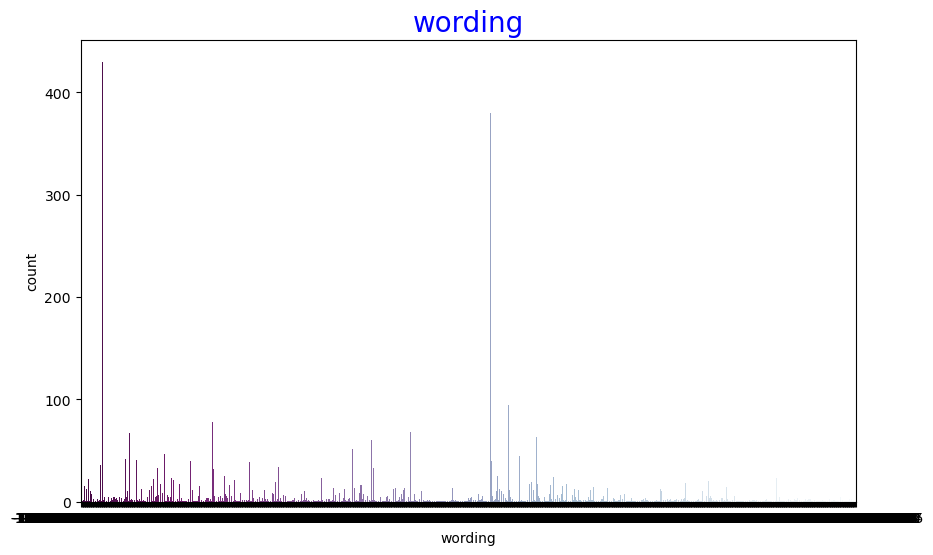

In [141]:
plt.figure(figsize=(10,6))
sns.countplot(data=combined,x='wording',palette='BuPu_r')
plt.title('wording',size=20,color='Blue')
plt.show()

In [142]:
combined['wording'].value_counts(normalize=True)*100

-1.461245    5.998047
 0.380538    5.300600
 0.503833    3.989399
-1.505073    2.413168
-0.168734    2.385270
               ...   
 1.207819    0.013949
 0.240178    0.013949
 1.040696    0.013949
 1.420841    0.013949
-0.292990    0.013949
Name: wording, Length: 1134, dtype: float64

In [143]:
train.shape[0]

7165

In [144]:
new_train=combined.iloc[0:train.shape[0],:]

In [145]:
new_test=combined.iloc[train.shape[0]:,:]

In [146]:
train.shape,new_train.shape,test.shape,new_test.shape

((7165, 5), (7165, 5), (4, 3), (4, 5))

In [148]:
num_cols = combined.select_dtypes(include='number')
cat_cos = combined.select_dtypes(include='object')

In [149]:
sig_num=[]
for i in num_cols:
    zero=new_train.loc[new_train['wording']==0,i]
    one=new_train.loc[new_train['wording']==1,i]
    two=new_train.loc[new_train['wording']==2,i]
    teststat,pval=stats.f_oneway(zero,one,two)
    if pval<0.05:
        sig_num.append(i)
        print(i)

/opt/conda/lib/python3.10/site-packages/scipy/stats/stats.py:3621: F_onewayBadInputSizesWarning: at least one input has length 0
  warnings.warn(F_onewayBadInputSizesWarning('at least one input '


In [152]:
train_new=new_train.loc[:,sig_cat+sig_num]

In [153]:
test_new=new_test.loc[:,sig_cat+sig_num]

In [154]:
test_new

""
0
1
2
3


In [155]:
train_new

""
0
1
2
3
4
...
7160
7161
7162
7163


In [ ]:
# Scaling the col

In [160]:
scaling=[]

In [161]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [162]:
for i in  scaling:
    train_new.loc[:,i]=scaler.fit_transform(pd.DataFrame(train_new.loc[:,i]))
    test_new.loc[:,i]=scaler.transform(pd.DataFrame(test_new.loc[:,i]))